In [1]:
# ============================================================
# Imports
# ============================================================

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score, 
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report
)

pd.set_option('display.max_columns', None)

print("✓ Imports successful")

✓ Imports successful


In [2]:
# ============================================================
# Best Model Evaluation
# ============================================================

# Load the best model
model_path = Path('../models/logistic_regression_model.pkl')

with open(model_path, 'rb') as f:
    best_model = pickle.load(f)

# Load the test data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print(f"\n✓ Model loaded: {model_path}")
print(f"✓ Test data: {X_test.shape}")

MODEL EVALUATION

✓ Model loaded: ..\models\logistic_regression_model.pkl
✓ Test data: (13846, 14)


c:\Users\seka_\Portfolio_projects\call-result-prediction\venv_ml\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.4.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# ============================================================
# Predictions
# ============================================================

# Predictions of probabilities
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Predictions of classes (threshold = 0.5)
y_pred = (y_pred_proba >= 0.5).astype(int)

print(f"\n Predictions:")
print(f"  Probability range: [{y_pred_proba.min():.3f}, {y_pred_proba.max():.3f}]")
print(f"  Predicted positives (threshold=0.5): {y_pred.sum()} / {len(y_pred)} ({y_pred.mean():.2%})")


 Predictions:
  Probability range: [0.292, 0.617]
  Predicted positives (threshold=0.5): 1922 / 13846 (13.88%)


ROC CURVE ANALYSIS

 ROC-AUC: 0.6013


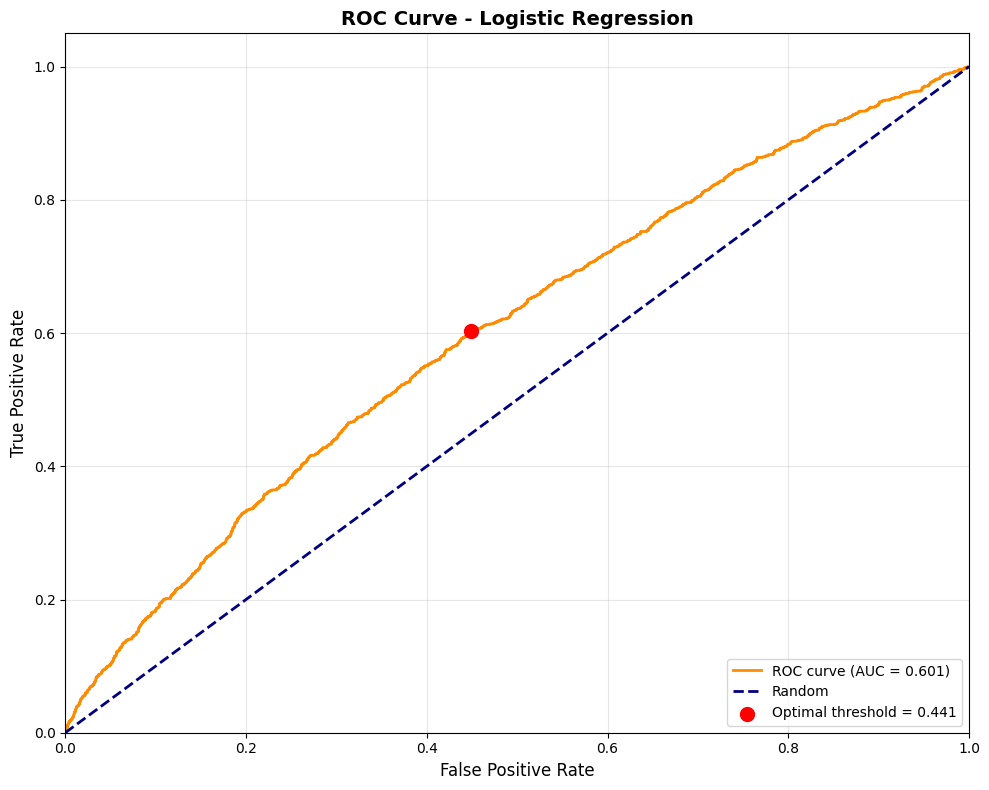


 Optimal Threshold: 0.441
   At this threshold: TPR = 0.604, FPR = 0.449


In [7]:
# ============================================================
# ROC-AUC and ROC Curve
# ============================================================

print("=" * 60)
print("ROC CURVE ANALYSIS")
print("=" * 60)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n ROC-AUC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Visualize ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')

# Find optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=100, 
            label=f'Optimal threshold = {optimal_threshold:.3f}', zorder=3)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Optimal Threshold: {optimal_threshold:.3f}")
print(f"   At this threshold: TPR = {tpr[optimal_idx]:.3f}, FPR = {fpr[optimal_idx]:.3f}")

PRECISION-RECALL ANALYSIS

 PR-AUC: 0.1261


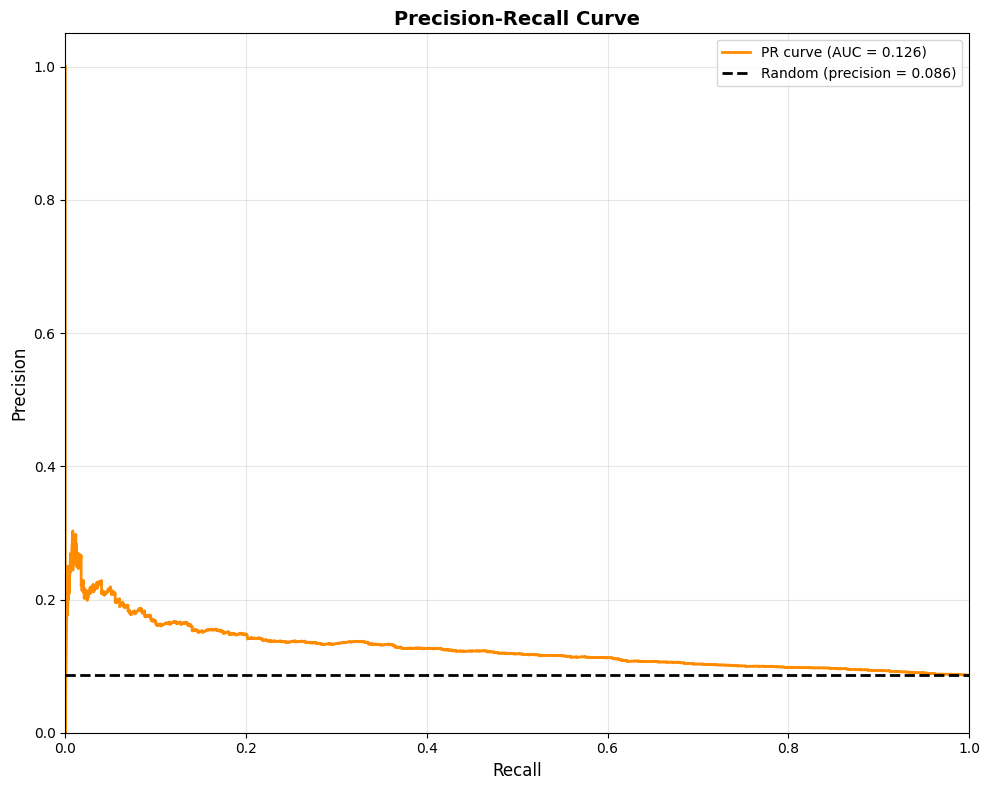

In [8]:
# ============================================================
# Precision-Recall Curve
# ============================================================

print("=" * 60)
print("PRECISION-RECALL ANALYSIS")
print("=" * 60)

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

print(f"\n PR-AUC: {pr_auc:.4f}")

# Visualize Precision-Recall Curve
plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')

# Baseline (random classifier)
baseline_precision = y_test.sum() / len(y_test)
plt.plot([0, 1], [baseline_precision, baseline_precision], 'k--', lw=2, 
         label=f'Random (precision = {baseline_precision:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

CONFUSION MATRIX

 Confusion Matrix (threshold = 0.5):
  True Negatives:  10,994
  False Positives: 1,656
  False Negatives: 930
  True Positives:  266


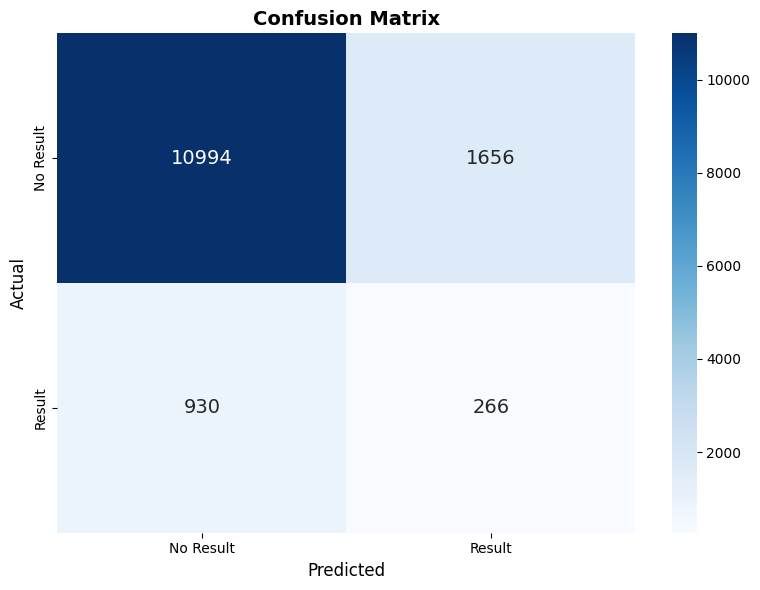


 Metrics (threshold = 0.5):
  Accuracy:  0.8132
  Precision: 0.1384
  Recall:    0.2224
  F1-Score:  0.1706


In [9]:
# ============================================================
# Confusion Matrix
# ============================================================

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)

print(f"\n Confusion Matrix (threshold = 0.5):")
print(f"  True Negatives:  {cm[0, 0]:,}")
print(f"  False Positives: {cm[0, 1]:,}")
print(f"  False Negatives: {cm[1, 0]:,}")
print(f"  True Positives:  {cm[1, 1]:,}")

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['No Result', 'Result'],
            yticklabels=['No Result', 'Result'],
            annot_kws={"size": 14})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n Metrics (threshold = 0.5):")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

In [10]:
# ============================================================
# Classification Report
# ============================================================

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print("\n" + classification_report(y_test, y_pred, 
                                   target_names=['No Result', 'Result'],
                                   digits=4))

CLASSIFICATION REPORT

              precision    recall  f1-score   support

   No Result     0.9220    0.8691    0.8948     12650
      Result     0.1384    0.2224    0.1706      1196

    accuracy                         0.8132     13846
   macro avg     0.5302    0.5457    0.5327     13846
weighted avg     0.8543    0.8132    0.8322     13846



FEATURE IMPORTANCE

 Top 10 Most Important Features:

                feature  importance
             risk_score    0.152369
             is_weekend    0.129553
client_prev_result_rate    0.068191
     preferred_language    0.053628
     client_call_number    0.046951
                   hour    0.039476
           product_type    0.021595
     debt_amount_bucket    0.018362
                segment    0.008399
               treename    0.008399


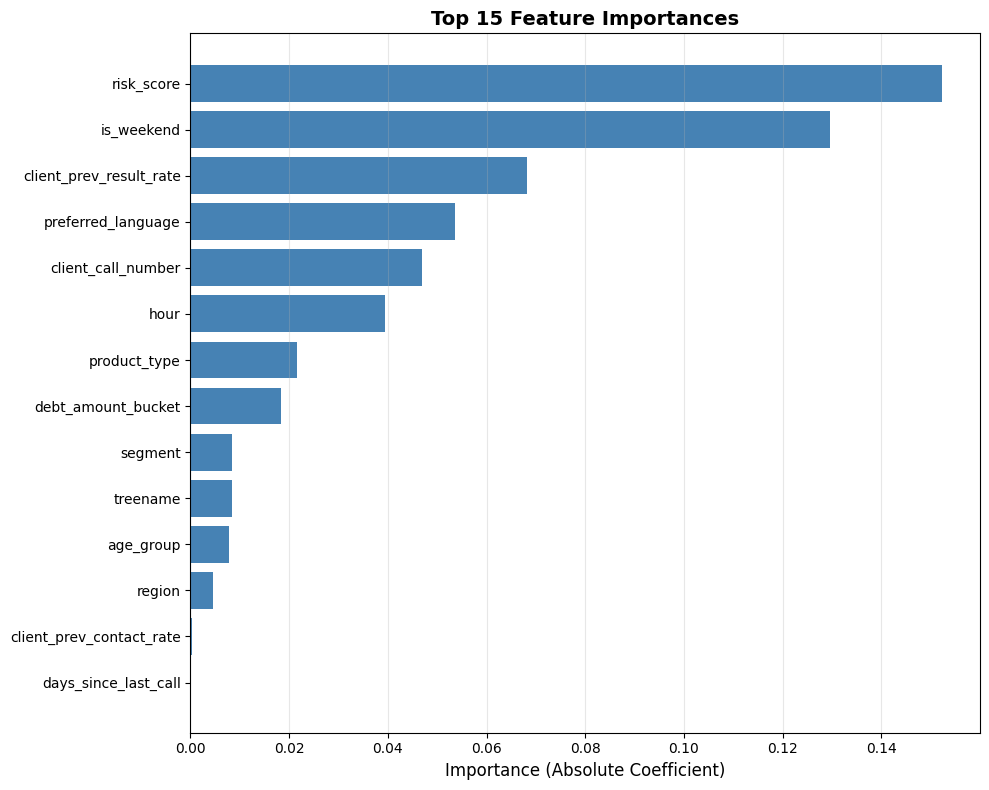

In [12]:
# ============================================================
# Feature Importance
# ============================================================

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

# Feature importance for logistic regression
if hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n Top 10 Most Important Features:\n")
print(feature_importance_df.head(10).to_string(index=False))

# Visualize Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance_df.head(15)
ax.barh(top_features['feature'], top_features['importance'], color='steelblue')
ax.set_xlabel('Importance (Absolute Coefficient)', fontsize=12)
ax.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

THRESHOLD OPTIMIZATION

 Performance at Different Thresholds:

 Threshold   TP    FP   FN    TN  Precision   Recall       F1
       0.3 1196 12645    0     5   0.086410 1.000000 0.159074
       0.4 1003  9315  193  3335   0.097209 0.838629 0.174223
       0.5  266  1656  930 10994   0.138398 0.222408 0.170622
       0.6    0     6 1196 12644   0.000000 0.000000 0.000000
       0.7    0     0 1196 12650   0.000000 0.000000 0.000000


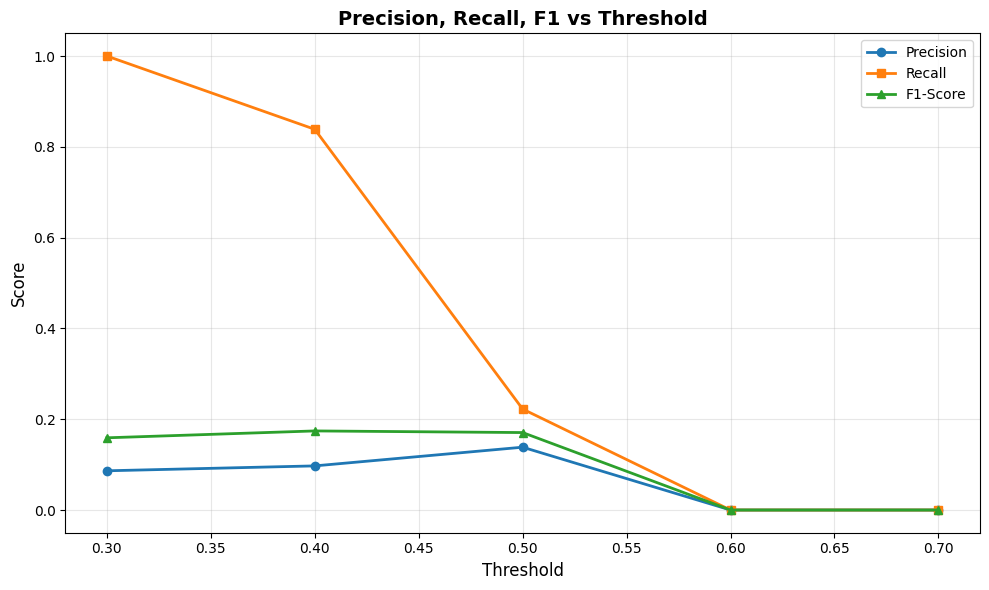

In [13]:
# ============================================================
# Threshold Analysis
# ============================================================

print("=" * 60)
print("THRESHOLD OPTIMIZATION")
print("=" * 60)

# Test a range of thresholds to see how metrics change
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds_to_test:
    y_pred_t = (y_pred_proba >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_t = 2 * (precision_t * recall_t) / (precision_t + recall_t) if (precision_t + recall_t) > 0 else 0
    
    threshold_results.append({
        'Threshold': threshold,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Precision': precision_t,
        'Recall': recall_t,
        'F1': f1_t
    })

threshold_df = pd.DataFrame(threshold_results)

print("\n Performance at Different Thresholds:\n")
print(threshold_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='s', label='Recall', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['F1'], marker='^', label='F1-Score', linewidth=2)
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall, F1 vs Threshold', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

PREDICTION DISTRIBUTION


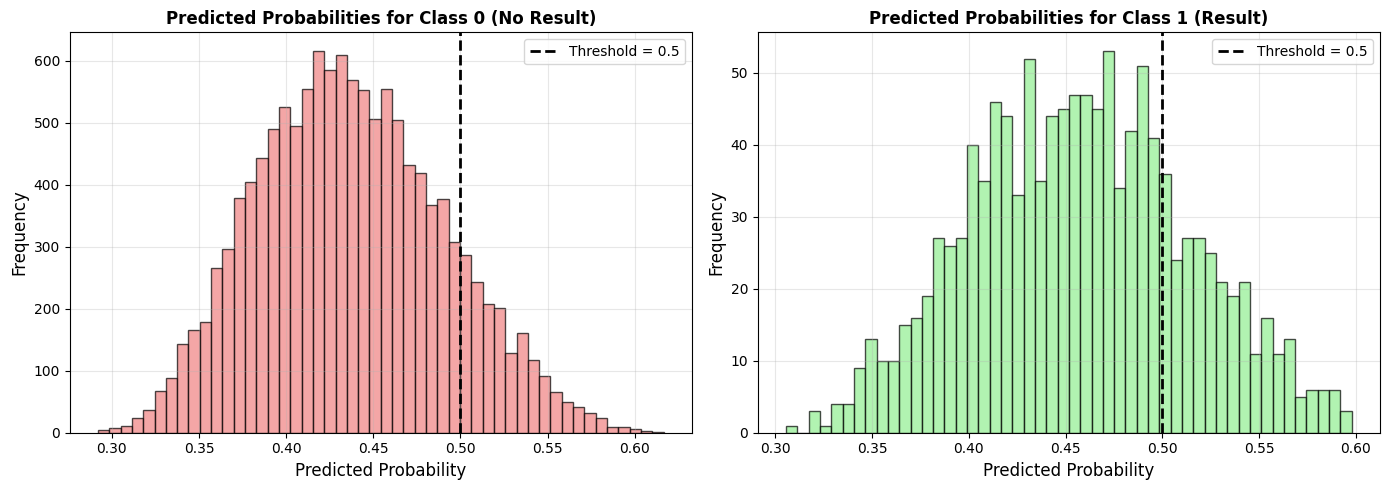


 Prediction Statistics:
  Class 0 mean prob: 0.437
  Class 1 mean prob: 0.457


In [14]:
# ============================================================
# Prediction Distribution
# ============================================================

print("=" * 60)
print("PREDICTION DISTRIBUTION")
print("=" * 60)

# Distribution of predicted probabilities by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# For class 0 (No Result)
axes[0].hist(y_pred_proba[y_test == 0], bins=50, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Predicted Probabilities for Class 0 (No Result)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# For class 1 (Result)
axes[1].hist(y_pred_proba[y_test == 1], bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Predicted Probabilities for Class 1 (Result)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Prediction Statistics:")
print(f"  Class 0 mean prob: {y_pred_proba[y_test == 0].mean():.3f}")
print(f"  Class 1 mean prob: {y_pred_proba[y_test == 1].mean():.3f}")

BUSINESS IMPACT ANALYSIS


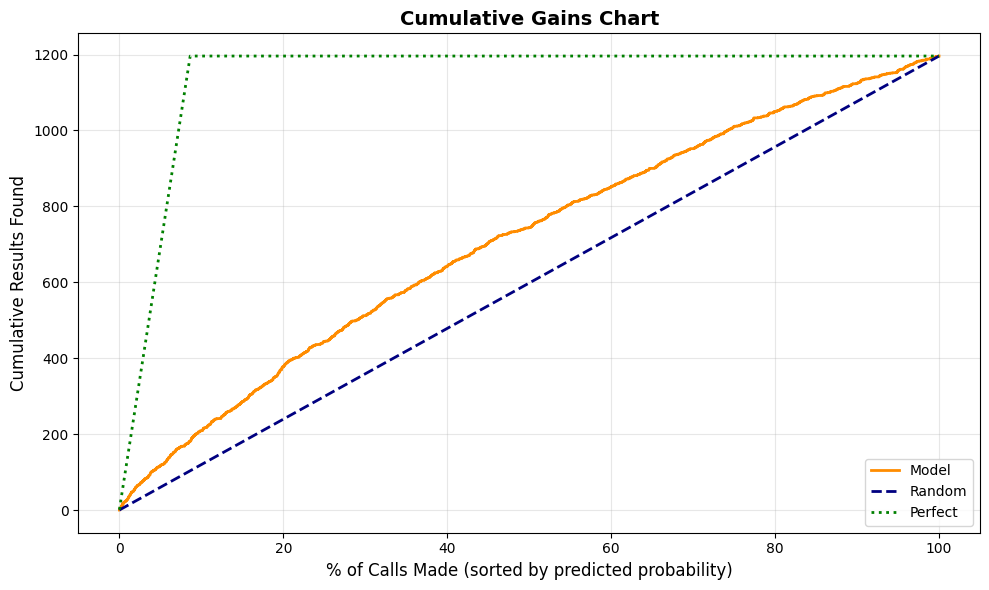


 Lift Analysis:

  % Calls | Results Found | Lift
  ----------------------------------------
      10% |         209.0 |  1.75x
      20% |         377.0 |  1.58x
      30% |         512.0 |  1.43x
      50% |         744.0 |  1.24x

 Interpretation:
  If we call only the top 20% of clients (sorted by model probability),
  we would find 377.0 results (31.5% of all results)


In [16]:
# ============================================================
# Business Impact Analysis
# ============================================================

print("=" * 60)
print("BUSINESS IMPACT ANALYSIS")
print("=" * 60)

# Suppose the model is used for prioritizing calls
# We only call the top-N clients based on predicted probability

total_calls = len(y_test)
total_results = y_test.sum()

# Sort by descending probability
sorted_indices = np.argsort(y_pred_proba)[::-1]
y_test_sorted = y_test.iloc[sorted_indices].values

# Calculate cumulative results
cumulative_results = np.cumsum(y_test_sorted)
call_percentages = np.arange(1, total_calls + 1) / total_calls * 100

# Visualize Lift Curve
fig, ax = plt.subplots(figsize=(10, 6))

# Model curve
ax.plot(call_percentages, cumulative_results, linewidth=2, label='Model', color='darkorange')

# Random baseline
ax.plot(call_percentages, call_percentages / 100 * total_results, 
        linewidth=2, linestyle='--', label='Random', color='navy')

# Perfect model
perfect_results = np.minimum(np.arange(1, total_calls + 1), total_results)
ax.plot(call_percentages, perfect_results, linewidth=2, linestyle=':', label='Perfect', color='green')

ax.set_xlabel('% of Calls Made (sorted by predicted probability)', fontsize=12)
ax.set_ylabel('Cumulative Results Found', fontsize=12)
ax.set_title('Cumulative Gains Chart', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Считаем lift для разных процентилей
percentiles = [10, 20, 30, 50]
print("\n Lift Analysis:\n")
print("  % Calls | Results Found | Lift")
print("  " + "-" * 40)

for pct in percentiles:
    n_calls = int(total_calls * pct / 100)
    results_found = cumulative_results[n_calls - 1]
    expected_random = total_results * pct / 100
    lift = results_found / expected_random if expected_random > 0 else 0
    
    print(f"  {pct:>6}% | {results_found:>13} | {lift:>5.2f}x")

print("\n Interpretation:")
print("  If we call only the top 20% of clients (sorted by model probability),")
top_20_results = cumulative_results[int(total_calls * 0.2) - 1]
top_20_pct = top_20_results / total_results * 100
print(f"  we would find {top_20_results} results ({top_20_pct:.1f}% of all results)")

In [17]:
# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)

print(f"\n Model: Logistic Regression")
print(f"\n Key Metrics:")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print(f"  PR-AUC:    {pr_auc:.4f}")
print(f"  Precision: {precision:.4f} (at threshold=0.5)")
print(f"  Recall:    {recall:.4f} (at threshold=0.5)")
print(f"  F1-Score:  {f1:.4f}")

print(f"\n Business Impact:")
print(f"  By calling top 20% of clients (sorted by probability),")
print(f"  we capture {top_20_pct:.1f}% of all potential results")

print("\n" + "=" * 60)
print("✓✓✓ EVALUATION COMPLETE ✓✓✓")
print("=" * 60)


EVALUATION SUMMARY

 Model: Logistic Regression

 Key Metrics:
  ROC-AUC:   0.6013
  PR-AUC:    0.1261
  Precision: 0.1384 (at threshold=0.5)
  Recall:    0.2224 (at threshold=0.5)
  F1-Score:  0.1706

 Business Impact:
  By calling top 20% of clients (sorted by probability),
  we capture 31.5% of all potential results

✓✓✓ EVALUATION COMPLETE ✓✓✓
